<a href="https://colab.research.google.com/github/leirefdezloizaga/Diabetes-130-US-Hospitals-EDA-Markov-Chain-Analysis/blob/main/diabetes_analysis_markov.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.linalg import eig
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 6)
sns.set_theme(style='whitegrid')

In [2]:
from google.colab import files
uploaded = files.upload()

Saving diabetic_data.csv to diabetic_data.csv


BLOQUE 1: PREPARAR LOS DATOS

In [3]:
df = pd.read_csv('diabetic_data.csv', na_values='?')
df = df.drop_duplicates(subset='encounter_id')

In [5]:
df['readmitted_30'] = (df['readmitted'] == '<30').astype(int)

In [6]:
DRUG_COLS = [
    'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
    'glimepiride', 'acetohexamide', 'glipizide', 'glyburide',
    'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose',
    'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton',
    'insulin', 'glyburide-metformin', 'glipizide-metformin',
    'glimepiride-pioglitazone', 'metformin-rosiglitazone',
    'metformin-pioglitazone'
]
drug_num_cols = [c for c in DRUG_COLS if c in df.columns]
df['any_antidiabetic'] = (df[drug_num_cols].ne('No')).any(axis=1).astype(int)

print(f"Dataset listo: {len(df):,} encuentros")

Dataset listo: 101,766 encuentros


BLOQUE 2: ASIGNAR ESTADO A CADA ENCUENTRO

In [7]:
ESTADOS = ['SIN_TTO', 'ORAL', 'INSULINA', 'REINGRESO']

def asignar_estado(row):
    if row['readmitted_30'] == 1:
        return 'REINGRESO'
    elif row['insulin'] != 'No':
        return 'INSULINA'
    elif row['any_antidiabetic'] == 1:
        return 'ORAL'
    else:
        return 'SIN_TTO'

df['estado'] = df.apply(asignar_estado, axis=1)

print("\nDistribución de estados en el dataset:")
dist = df['estado'].value_counts()
for estado in ESTADOS:
    n = dist.get(estado, 0)
    print(f"  {estado:<12}: {n:>6,}  ({n/len(df)*100:.1f}%)")


Distribución de estados en el dataset:
  SIN_TTO     : 21,157  (20.8%)
  ORAL        : 21,470  (21.1%)
  INSULINA    : 47,782  (47.0%)
  REINGRESO   : 11,357  (11.2%)


BLOQUE 3: EXTRAER PARES DE TRANSICIÓN

In [8]:
df_ord = (df[['patient_nbr', 'encounter_id', 'estado']]
            .sort_values(['patient_nbr', 'encounter_id']))

df_ord['estado_sig'] = (df_ord
                          .groupby('patient_nbr')['estado']
                          .shift(-1))

In [9]:
trans = df_ord.dropna(subset=['estado_sig']).copy()

n_pares      = len(trans)
n_pac_multi  = (df.groupby('patient_nbr').size() > 1).sum()

print(f"\nPacientes con más de 1 encuentro: {n_pac_multi:,}")
print(f"Pares de transición disponibles:  {n_pares:,}")
print(f"\nConteo crudo de transiciones (filas=origen, columnas=destino):")
print(pd.crosstab(trans['estado'], trans['estado_sig']))


Pacientes con más de 1 encuentro: 16,773
Pares de transición disponibles:  30,248

Conteo crudo de transiciones (filas=origen, columnas=destino):
estado_sig  INSULINA  ORAL  REINGRESO  SIN_TTO
estado                                        
INSULINA        8395  1020       1977     1047
ORAL            1408  2347        752      692
REINGRESO       3655  1354       1701     1423
SIN_TTO         1178   606        634     2059


BLOQUE 4: CONSTRUIR LA MATRIZ DE TRANSICIÓN

In [10]:
conteo_norm = pd.crosstab(
    trans['estado'],
    trans['estado_sig'],
    normalize='index'
).round(4)

# Asegurar orden fijo y rellenar ceros si algún estado no aparece
P_df = conteo_norm.reindex(index=ESTADOS, columns=ESTADOS, fill_value=0)
P    = P_df.values   # array numpy para cálculos

print("\nMATRIZ DE TRANSICIÓN P (probabilidades):")
print(P_df.to_string())

print("\nDiagonal (probabilidad de quedarse en el mismo estado):")
for i, est in enumerate(ESTADOS):
    print(f"  {est:<12}: {P[i,i]:.3f}")


MATRIZ DE TRANSICIÓN P (probabilidades):
estado_sig  SIN_TTO    ORAL  INSULINA  REINGRESO
estado                                          
SIN_TTO      0.4599  0.1354    0.2631     0.1416
ORAL         0.1331  0.4514    0.2708     0.1446
INSULINA     0.0842  0.0820    0.6749     0.1589
REINGRESO    0.1750  0.1665    0.4494     0.2091

Diagonal (probabilidad de quedarse en el mismo estado):
  SIN_TTO     : 0.460
  ORAL        : 0.451
  INSULINA    : 0.675
  REINGRESO   : 0.209


BLOQUE 5: VISUALIZAR LA MATRIZ — HEATMAP

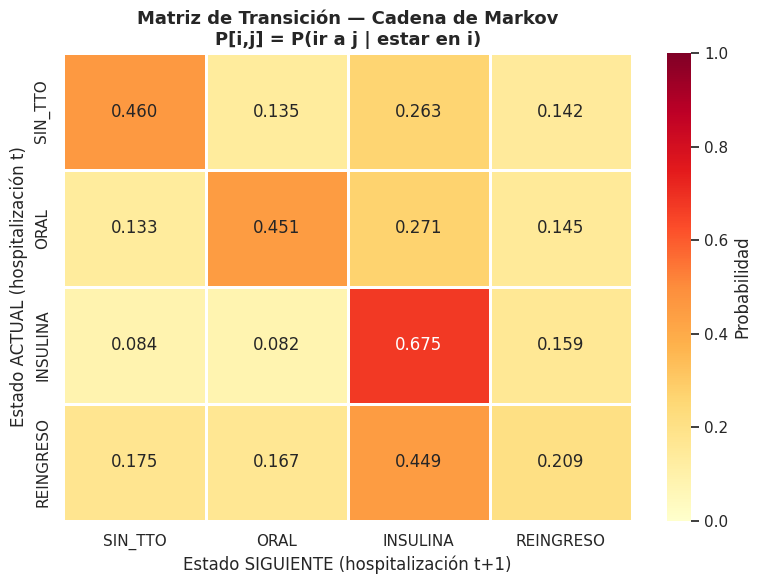

In [11]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    P_df,
    annot=True, fmt='.3f',
    cmap='YlOrRd',
    linewidths=0.8,
    vmin=0, vmax=1,
    ax=ax,
    cbar_kws={'label': 'Probabilidad'}
)
ax.set_title('Matriz de Transición — Cadena de Markov\n'
             'P[i,j] = P(ir a j | estar en i)', fontsize=13, fontweight='bold')
ax.set_xlabel('Estado SIGUIENTE (hospitalización t+1)')
ax.set_ylabel('Estado ACTUAL (hospitalización t)')
plt.tight_layout()
plt.savefig('markov_01_matriz.png', dpi=150, bbox_inches='tight')
plt.show()

BLOQUE 6: ESTADO ESTACIONARIO (STEADY STATE)

In [12]:
vals, vecs = eig(P.T)
idx_ss  = np.argmin(np.abs(vals - 1.0))
steady  = np.real(vecs[:, idx_ss])
steady  = np.abs(steady) / np.abs(steady).sum()   # normalizar, todo positivo

print("\nESTADO ESTACIONARIO π (cuota de mercado de largo plazo):")
for est, p in zip(ESTADOS, steady):
    print(f"  {est:<12}: {p:.4f}  →  {p*100:.1f}%")



ESTADO ESTACIONARIO π (cuota de mercado de largo plazo):
  SIN_TTO     : 0.1714  →  17.1%
  ORAL        : 0.1662  →  16.6%
  INSULINA    : 0.5007  →  50.1%
  REINGRESO   : 0.1617  →  16.2%


In [13]:
error_max = np.max(np.abs(steady @ P - steady))
print(f"\nVerificación π·P ≈ π  (error máximo: {error_max:.2e})")


Verificación π·P ≈ π  (error máximo: 8.32e-06)


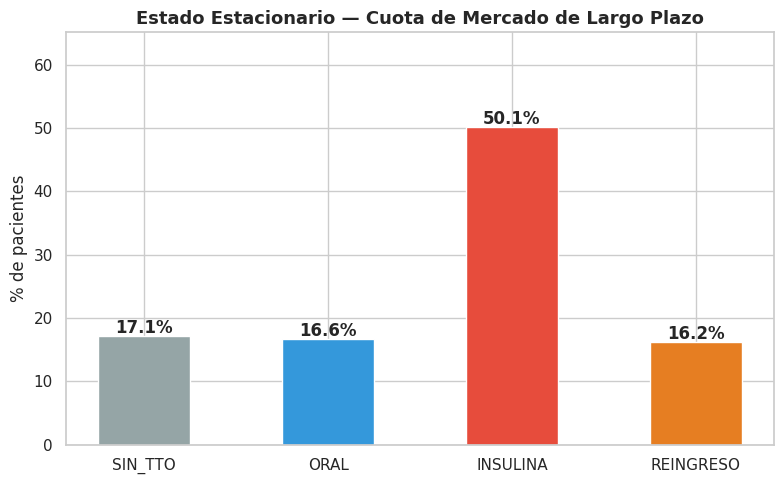

In [14]:
colores = ['#95a5a6', '#3498db', '#e74c3c', '#e67e22']
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(ESTADOS, steady * 100, color=colores, edgecolor='white', width=0.5)
for bar, v in zip(bars, steady):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.5, f'{v*100:.1f}%',
            ha='center', fontweight='bold', fontsize=12)
ax.set_title('Estado Estacionario — Cuota de Mercado de Largo Plazo',
             fontsize=13, fontweight='bold')
ax.set_ylabel('% de pacientes')
ax.set_ylim(0, max(steady) * 130)
plt.tight_layout()
plt.savefig('markov_02_steady_state.png', dpi=150, bbox_inches='tight')
plt.show()

BLOQUE 7: TIEMPO ESPERADO HASTA EL REINGRESO (ABSORCIÓN)

In [15]:
transitorios = ['SIN_TTO', 'ORAL', 'INSULINA']
idx_t = [ESTADOS.index(e) for e in transitorios]
Q     = P[np.ix_(idx_t, idx_t)]
N     = np.linalg.inv(np.eye(len(Q)) - Q)
t_abs = N.sum(axis=1)

print("\nHOSPITALIZACIONES ESPERADAS ANTES DEL PRIMER REINGRESO:")
for est, t in zip(transitorios, t_abs):
    print(f"  Desde {est:<12}: {t:.2f} hospitalizaciones")


HOSPITALIZACIONES ESPERADAS ANTES DEL PRIMER REINGRESO:
  Desde SIN_TTO     : 6.67 hospitalizaciones
  Desde ORAL        : 6.64 hospitalizaciones
  Desde INSULINA    : 6.48 hospitalizaciones


In [16]:
print("\nPROBABILIDAD DIRECTA DE REINGRESO (siguiente hospitalización):")
idx_rein = ESTADOS.index('REINGRESO')
for est in transitorios:
    i = ESTADOS.index(est)
    print(f"  Desde {est:<12}: {P[i, idx_rein]*100:.1f}%")



PROBABILIDAD DIRECTA DE REINGRESO (siguiente hospitalización):
  Desde SIN_TTO     : 14.2%
  Desde ORAL        : 14.5%
  Desde INSULINA    : 15.9%


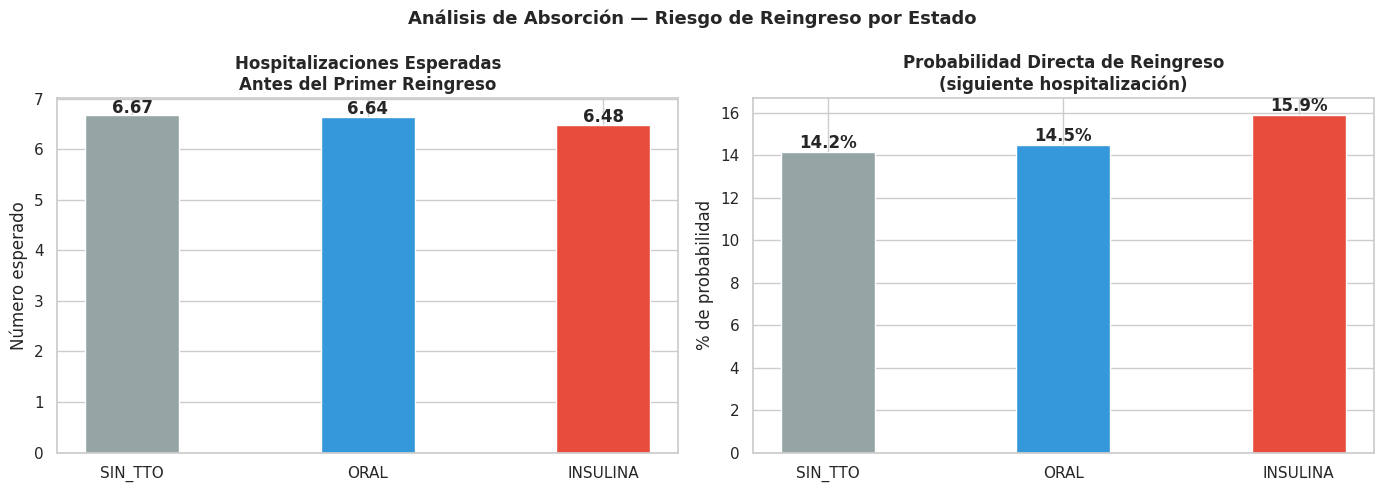

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colores_t = [colores[ESTADOS.index(e)] for e in transitorios]
bars = axes[0].bar(transitorios, t_abs,
                   color=colores_t, edgecolor='white', width=0.4)
for bar, t in zip(bars, t_abs):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.05, f'{t:.2f}',
                 ha='center', fontweight='bold', fontsize=12)
axes[0].set_title('Hospitalizaciones Esperadas\nAntes del Primer Reingreso',
                  fontsize=12, fontweight='bold')
axes[0].set_ylabel('Número esperado')

prob_rein = [P[ESTADOS.index(e), idx_rein] * 100 for e in transitorios]
bars2 = axes[1].bar(transitorios, prob_rein,
                    color=colores_t, edgecolor='white', width=0.4)
for bar, v in zip(bars2, prob_rein):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.2, f'{v:.1f}%',
                 ha='center', fontweight='bold', fontsize=12)
axes[1].set_title('Probabilidad Directa de Reingreso\n(siguiente hospitalización)',
                  fontsize=12, fontweight='bold')
axes[1].set_ylabel('% de probabilidad')

plt.suptitle('Análisis de Absorción — Riesgo de Reingreso por Estado',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('markov_03_absorcion.png', dpi=150, bbox_inches='tight')
plt.show()

BLOQUE 8: ANÁLISIS POST-REINGRESO


DESPUÉS DE UN REINGRESO, ¿qué tratamiento recibe el paciente?
  → SIN_TTO     : 17.5%
  → ORAL        : 16.7%
  → INSULINA    : 44.9%
  → REINGRESO   : 20.9%


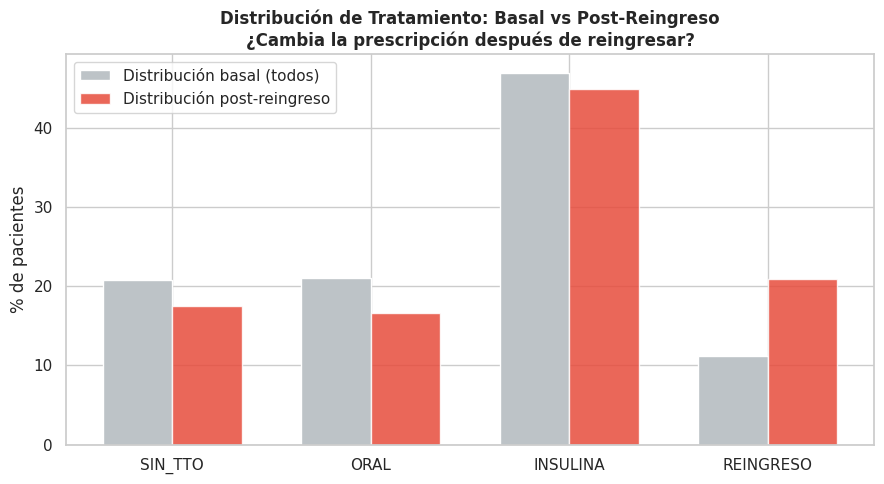

In [21]:
print("\nDESPUÉS DE UN REINGRESO, ¿qué tratamiento recibe el paciente?")
fila_rein = P_df.loc['REINGRESO']
for est, prob in fila_rein.items():
    print(f"  → {est:<12}: {prob*100:.1f}%")

# Comparar distribución post-reingreso vs distribución basal
fig, ax = plt.subplots(figsize=(9, 5))
x        = np.arange(len(ESTADOS))
ancho    = 0.35
dist_obs = df['estado'].value_counts(normalize=True).reindex(ESTADOS, fill_value=0)

ax.bar(x - ancho/2, dist_obs * 100,
       ancho, label='Distribución basal (todos)', color='#bdc3c7', edgecolor='white')
ax.bar(x + ancho/2, fila_rein * 100,
       ancho, label='Distribución post-reingreso', color='#e74c3c', edgecolor='white', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(ESTADOS)
ax.set_title('Distribución de Tratamiento: Basal vs Post-Reingreso\n'
             '¿Cambia la prescripción después de reingresar?',
             fontsize=12, fontweight='bold')
ax.set_ylabel('% de pacientes')
ax.legend()
plt.tight_layout()
plt.savefig('markov_05_post_reingreso.png', dpi=150, bbox_inches='tight')
plt.show()

BLOQUE 9: GRAFO DE LA CADENA

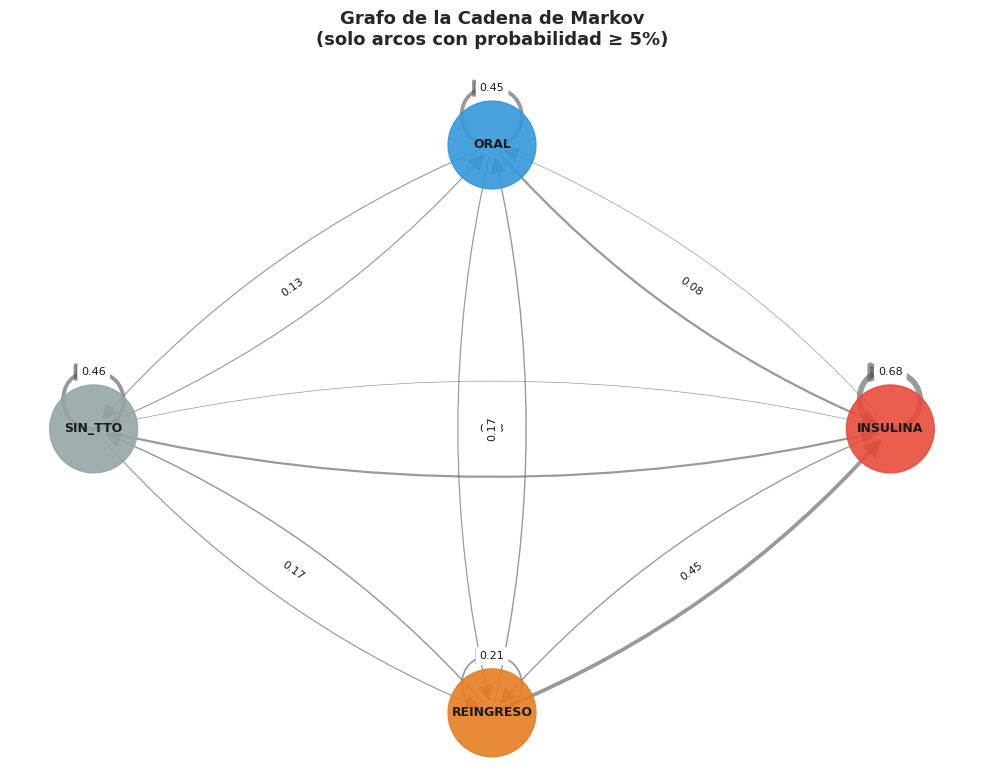

In [22]:
try:
    import networkx as nx

    G = nx.DiGraph()
    for i, origen in enumerate(ESTADOS):
        for j, destino in enumerate(ESTADOS):
            if P[i, j] >= 0.05:
                G.add_edge(origen, destino, weight=round(P[i, j], 3))

    pos = {'SIN_TTO': (-1, 0), 'ORAL': (0, 1),
           'INSULINA': (1, 0), 'REINGRESO': (0, -1)}

    fig, ax = plt.subplots(figsize=(10, 8))
    nx.draw_networkx_nodes(G, pos, node_color=colores,
                           node_size=4000, alpha=0.9, ax=ax)
    nx.draw_networkx_labels(G, pos, font_size=9,
                            font_weight='bold', ax=ax)
    pesos = [G[u][v]['weight'] for u, v in G.edges()]
    nx.draw_networkx_edges(G, pos,
                           width=[w * 6 for w in pesos],
                           edge_color='#555555', alpha=0.6,
                           connectionstyle='arc3,rad=0.12',
                           arrows=True, arrowsize=25, ax=ax)
    nx.draw_networkx_edge_labels(G, pos,
                                 {(u, v): f"{G[u][v]['weight']:.2f}"
                                  for u, v in G.edges()},
                                 font_size=8, ax=ax)
    ax.set_title('Grafo de la Cadena de Markov\n'
                 '(solo arcos con probabilidad ≥ 5%)',
                 fontsize=13, fontweight='bold')
    ax.axis('off')
    plt.tight_layout()
    plt.savefig('markov_06_grafo.png', dpi=150, bbox_inches='tight')
    plt.show()

except ImportError:
    print("Para el grafo ejecuta: !pip install networkx")

BLOQUE 10: RESUMEN EJECUTIVO — CADENA DE MARKOV

In [24]:
_ss   = steady
_t    = t_abs
_prob = [P[ESTADOS.index(e), ESTADOS.index('REINGRESO')] * 100
         for e in transitorios]

_lider_ss   = ESTADOS[np.argmax(_ss)]
_mejor_prot = transitorios[np.argmax(_t)]
_mayor_risk = transitorios[np.argmax(_prob)]

_dist_obs     = df['estado'].value_counts(normalize=True).reindex(ESTADOS, fill_value=0)
_post_rein    = P_df.loc['REINGRESO']
_delta_ins    = (_post_rein['INSULINA'] - _dist_obs['INSULINA']) * 100

print("\n" + "="*65)
print("RESUMEN EJECUTIVO — CADENA DE MARKOV")
print("="*65)
print(f"""
DATOS DE LA CADENA:
  Pares de transición usados : {n_pares:,}
  Pacientes con >1 encuentro : {n_pac_multi:,}

STEADY STATE (cuota de mercado de largo plazo):
  SIN_TTO   : {_ss[0]*100:.1f}%
  ORAL      : {_ss[1]*100:.1f}%
  INSULINA  : {_ss[2]*100:.1f}%
  REINGRESO : {_ss[3]*100:.1f}%
  → Estado dominante: {_lider_ss}

HOSPITALIZACIONES ESPERADAS ANTES DEL REINGRESO:
  SIN_TTO   : {_t[0]:.2f} hospitalizaciones
  ORAL      : {_t[1]:.2f} hospitalizaciones
  INSULINA  : {_t[2]:.2f} hospitalizaciones
  → Mayor protección: {_mejor_prot}

PROBABILIDAD DIRECTA DE REINGRESO (siguiente ingreso):
  SIN_TTO   : {_prob[0]:.1f}%
  ORAL      : {_prob[1]:.1f}%
  INSULINA  : {_prob[2]:.1f}%
  → Mayor riesgo: {_mayor_risk}

ANÁLISIS POST-REINGRESO:
  Tras reingresar, el uso de insulina {'aumenta' if _delta_ins > 0 else 'disminuye'}
  en {abs(_delta_ins):.1f} pp respecto a la distribución basal
  → {'El reingreso ES el trigger de intensificación hacia insulina' if _delta_ins > 0
     else 'El reingreso NO dispara la intensificación hacia insulina'}

IMPLICACIÓN:
  · El steady state define el TAM de largo plazo de cada terapia
  · El estado de mayor riesgo ({_mayor_risk}) es donde hay más
    oportunidad de intervención temprana
  · El momento post-reingreso {'es' if _delta_ins > 0 else 'no es'} el momento
    de mayor apertura al switch hacia insulina
""")

print("Archivos generados: markov_01_ a markov_06_*.png")



RESUMEN EJECUTIVO — CADENA DE MARKOV

DATOS DE LA CADENA:
  Pares de transición usados : 30,248
  Pacientes con >1 encuentro : 16,773

STEADY STATE (cuota de mercado de largo plazo):
  SIN_TTO   : 17.1%
  ORAL      : 16.6%
  INSULINA  : 50.1%
  REINGRESO : 16.2%
  → Estado dominante: INSULINA

HOSPITALIZACIONES ESPERADAS ANTES DEL REINGRESO:
  SIN_TTO   : 6.67 hospitalizaciones
  ORAL      : 6.64 hospitalizaciones
  INSULINA  : 6.48 hospitalizaciones
  → Mayor protección: SIN_TTO

PROBABILIDAD DIRECTA DE REINGRESO (siguiente ingreso):
  SIN_TTO   : 14.2%
  ORAL      : 14.5%
  INSULINA  : 15.9%
  → Mayor riesgo: INSULINA

ANÁLISIS POST-REINGRESO:
  Tras reingresar, el uso de insulina disminuye
  en 2.0 pp respecto a la distribución basal
  → El reingreso NO dispara la intensificación hacia insulina

IMPLICACIÓN:
  · El steady state define el TAM de largo plazo de cada terapia
  · El estado de mayor riesgo (INSULINA) es donde hay más
    oportunidad de intervención temprana
  · El momen